In [45]:
# Ячейка 1: Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

print("Библиотеки загружены")

Библиотеки загружены


In [46]:
# Ячейка 2: Загрузка витрины
mart_path = Path("../data/mart/variant_16")
mart_files = list(mart_path.glob("mart_daily_*.csv"))
latest_mart = max(mart_files, key=lambda f: f.stat().st_mtime)

df = pd.read_csv(latest_mart, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Добавляем скользящее среднее
df['cnt_events_7d'] = df['cnt_events'].rolling(window=7, min_periods=1).mean()

print(f"Загружено: {len(df)} дней, {df['date'].min().date()} - {df['date'].max().date()}")

Загружено: 24 дней, 2026-03-08 - 2026-04-06


In [47]:
# Ячейка 3: Функция сохранения
def save_fig(fig, filename):
    figures_dir = Path("../docs/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    filepath = figures_dir / filename
    fig.savefig(filepath, dpi=150, bbox_inches='tight', facecolor='white')
    print(f"Сохранён: {filepath}")
    return filepath

Сохранён: ..\docs\figures\week7_timeseries.png


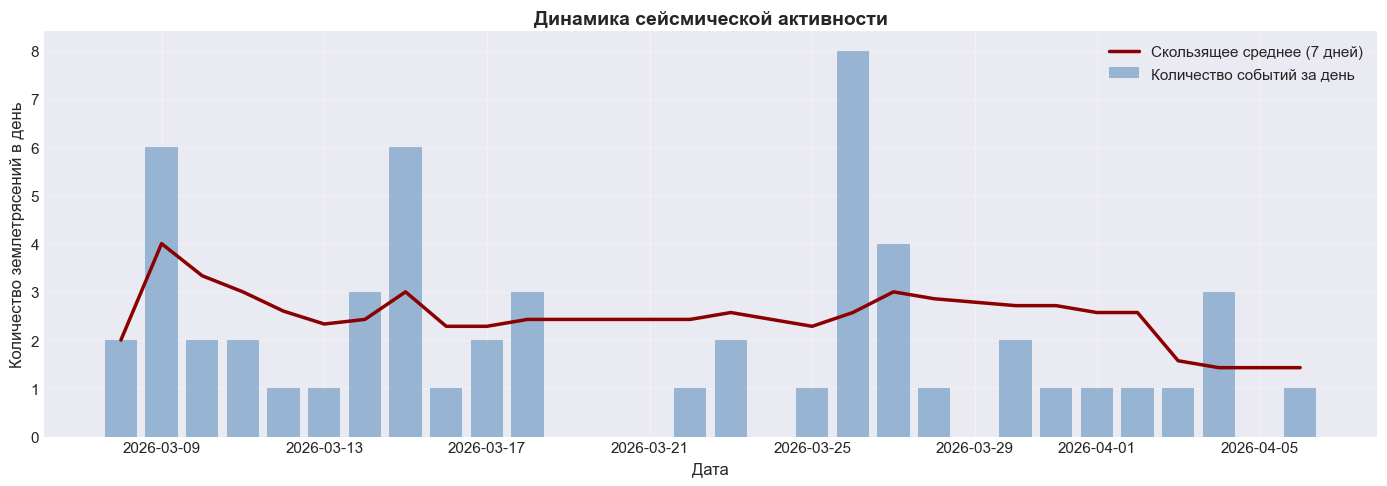

In [48]:
# Ячейка 4: График №1 - Временной ряд (динамика активности)
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(df['date'], df['cnt_events'], alpha=0.5, label='Количество событий за день', color='steelblue')
ax.plot(df['date'], df['cnt_events_7d'], color='darkred', linewidth=2.5, label='Скользящее среднее (7 дней)')
ax.set_title('Динамика сейсмической активности', fontsize=14, fontweight='bold')
ax.set_xlabel('Дата', fontsize=12)
ax.set_ylabel('Количество землетрясений в день', fontsize=12)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'week7_timeseries.png')
plt.show()

Сохранён: ..\docs\figures\week7_distribution.png


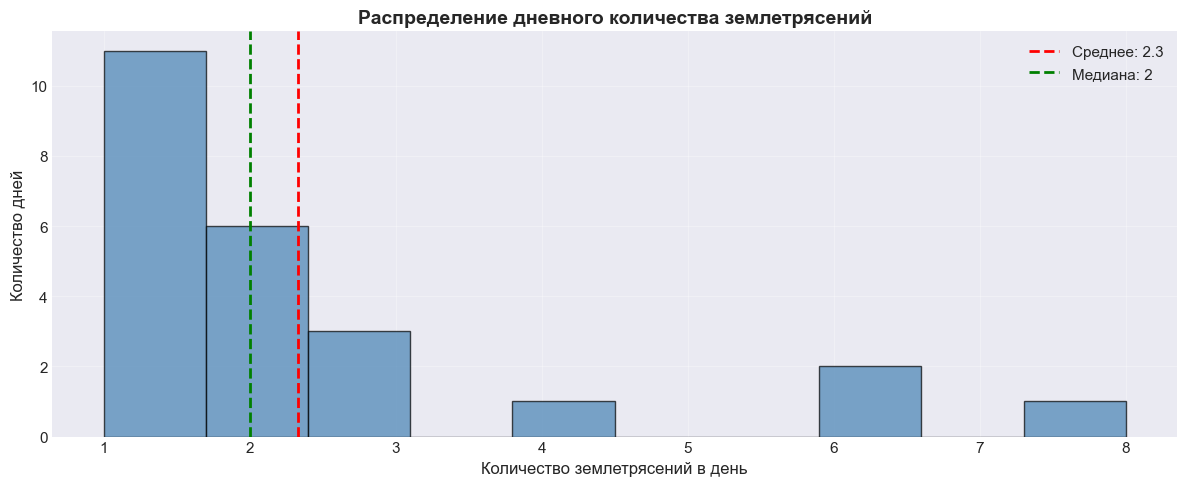

In [49]:
# Ячейка 5: График №2 - Распределение (гистограмма)
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['cnt_events'], bins=10, edgecolor='black', color='steelblue', alpha=0.7)
ax.axvline(df['cnt_events'].mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {df["cnt_events"].mean():.1f}')
ax.axvline(df['cnt_events'].median(), color='green', linestyle='--', linewidth=2, label=f'Медиана: {df["cnt_events"].median():.0f}')
ax.set_title('Распределение дневного количества землетрясений', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество землетрясений в день', fontsize=12)
ax.set_ylabel('Количество дней', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig(fig, 'week7_distribution.png')
plt.show()

Сохранён: ..\docs\figures\week7_ranking.png


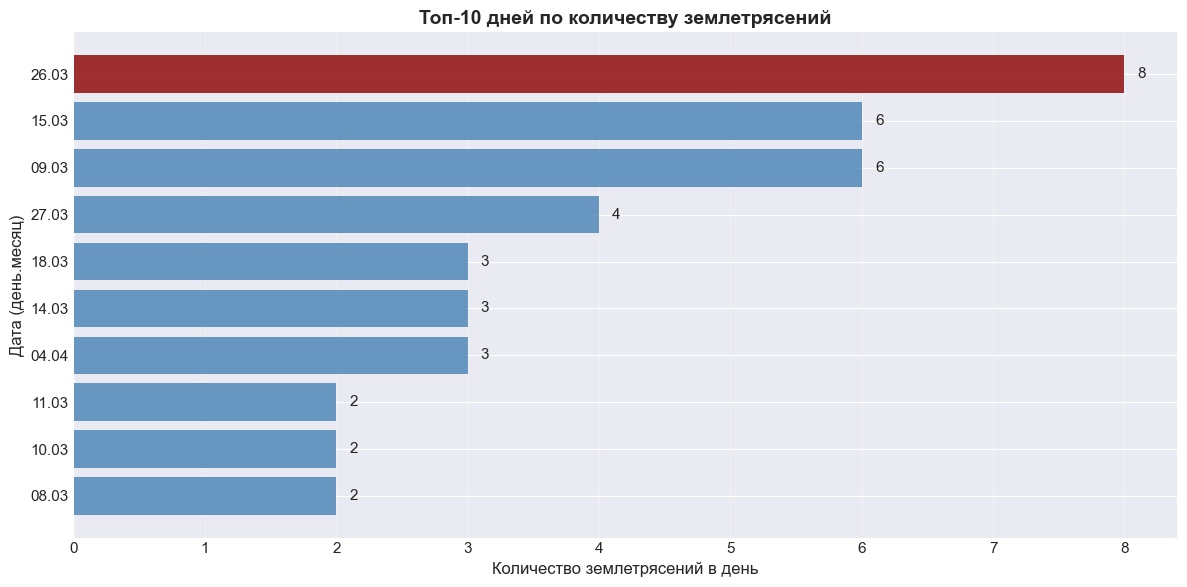

In [50]:
# Ячейка 6: График №3 - Ранжирование (топ дней по активности)
fig, ax = plt.subplots(figsize=(12, 6))

top_days = df.nlargest(10, 'cnt_events')[['date', 'cnt_events']].copy()
top_days['date_str'] = top_days['date'].dt.strftime('%d.%m')
top_days = top_days.sort_values('cnt_events', ascending=True)

colors = ['darkred' if i == len(top_days)-1 else 'steelblue' for i in range(len(top_days))]
bars = ax.barh(top_days['date_str'], top_days['cnt_events'], color=colors, alpha=0.8)

ax.set_title('Топ-10 дней по количеству землетрясений', fontsize=14, fontweight='bold')
ax.set_xlabel('Количество землетрясений в день', fontsize=12)
ax.set_ylabel('Дата (день.месяц)', fontsize=12)

for bar, val in zip(bars, top_days['cnt_events']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val), va='center')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
save_fig(fig, 'week7_ranking.png')
plt.show()

In [51]:
# Ячейка 7: Выводы по визуализациям
from IPython.display import Markdown, display

peak_day = df.loc[df['cnt_events'].idxmax()]
median_events = df['cnt_events'].median()
q95_events = df['cnt_events'].quantile(0.95)
avg_events = df['cnt_events'].mean()
max_events = df['cnt_events'].max()

top3_days = df.nlargest(3, 'cnt_events')[['date', 'cnt_events']]
anomaly_threshold = df['cnt_events'].mean() + df['cnt_events'].std()
anomaly_days_pct = (df['cnt_events'] > anomaly_threshold).mean() * 100

conclusion_text = f"""
## Выводы по визуальному анализу сейсмической активности

### 1. Временной ряд: активность кластеризуется во времени
Сейсмическая активность **не распределена равномерно**.  
В анализируемом периоде наблюдается пик активности:
- **{peak_day['date'].date()}** — максимальное количество событий: **{peak_day['cnt_events']} землетрясений**

**Вывод:** В сейсмической активности наблюдаются **периоды затишья и периоды всплесков**. Для полноценного мониторинга необходимо отслеживать такие кластеры событий.

---

### 2. Распределение: типичный день — мало событий, редкие всплески
- **Медиана дневных событий:** {median_events:.0f} землетрясений
- **Среднее значение:** {avg_events:.1f}
- **95-й перцентиль:** {q95_events:.0f} событий (только 5% дней превышают этот порог)
- **{anomaly_days_pct:.1f}% дней** имеют аномально высокую активность

**Вывод:** В большинство дней фиксируется **фоновая активность** (1-2 события). Аномальные всплески редки, но именно они определяют повышенный риск.

---

### 3. Ранжирование: дни-лидеры по активности
| Дата | Количество событий |
|------|-------------------|
| {top3_days.iloc[0]['date'].date()} | {top3_days.iloc[0]['cnt_events']} |
| {top3_days.iloc[1]['date'].date()} | {top3_days.iloc[1]['cnt_events']} |
| {top3_days.iloc[2]['date'].date()} | {top3_days.iloc[2]['cnt_events']} |

**Вывод:** Даже в рамках одного региона активность может сильно различаться по дням. Выявление таких дней позволяет анализировать возможные триггеры.

"""

display(Markdown(conclusion_text))


## Выводы по визуальному анализу сейсмической активности

### 1. Временной ряд: активность кластеризуется во времени
Сейсмическая активность **не распределена равномерно**.  
В анализируемом периоде наблюдается пик активности:
- **2026-03-26** — максимальное количество событий: **8 землетрясений**

**Вывод:** В сейсмической активности наблюдаются **периоды затишья и периоды всплесков**. Для полноценного мониторинга необходимо отслеживать такие кластеры событий.

---

### 2. Распределение: типичный день — мало событий, редкие всплески
- **Медиана дневных событий:** 2 землетрясений
- **Среднее значение:** 2.3
- **95-й перцентиль:** 6 событий (только 5% дней превышают этот порог)
- **12.5% дней** имеют аномально высокую активность

**Вывод:** В большинство дней фиксируется **фоновая активность** (1-2 события). Аномальные всплески редки, но именно они определяют повышенный риск.

---

### 3. Ранжирование: дни-лидеры по активности
| Дата | Количество событий |
|------|-------------------|
| 2026-03-26 | 8 |
| 2026-03-09 | 6 |
| 2026-03-15 | 6 |

**Вывод:** Даже в рамках одного региона активность может сильно различаться по дням. Выявление таких дней позволяет анализировать возможные триггеры.



In [52]:
# Ячейка 8: Сохранение выводов
output_path = Path("../docs/analysis_conclusions.md")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    f.write(conclusion_text)

print(f"Выводы сохранены в: {output_path}")

Выводы сохранены в: ..\docs\analysis_conclusions.md
